1. Import All Libraries

In [39]:
%matplotlib inline
import pandas as pd #loads and manipulates the Excel dataset
import numpy as np #provides numerical operations and array handling
from sklearn.ensemble import RandomForestClassifier #imports Random Forest model
from sklearn.linear_model import LogisticRegression # imports Logistic Regression model
from sklearn.tree import DecisionTreeClassifier #imports Decision Tree model
from sklearn.model_selection import train_test_split, GridSearchCV #splits data into training and testing sets. GridSearchCV tries many combinations of hyperparameters to find the best ones
from sklearn.preprocessing import LabelEncoder #converts text categories like "Male"/"Female" into numbers 0 and 1
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay #tools to measure how good the model is
)
from imblearn.over_sampling import SMOTE #handles class imbalance by creating synthetic samples of the minority class
from xgboost import XGBClassifier #provides XGBoost model which typically outperforms Random Forest on tabular data
import matplotlib #draws the comparison charts and confusion matrix
import matplotlib.pyplot as plt
import joblib #saves and loads the trained model as a .pkl file
import warnings
warnings.filterwarnings('ignore') #hides non-critical warning messages to keep output clean


2. Load and Understand the Data : Load the Dataset

In [40]:
"""
Step 1: Load dataset and subset to the 11 selected features (+ CustomerID, Churn)
Step 2: Clean — median-impute missing numerics, encode Gender & MaritalStatus
"""
import pandas as pd

# ---- Step 1: Load & subset ----
df_raw = pd.read_excel(
    "../datasets/E Commerce Dataset.xlsx",
    sheet_name="E Comm"
)

KEEP = [
    'CustomerID', 'Churn',
    'Tenure', 'Gender', 'HourSpendOnApp', 'SatisfactionScore',
    'MaritalStatus', 'NumberOfAddress', 'Complain', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder', 'CashbackAmount',
]

df = df_raw[KEEP].copy()

print('=== STEP 1: Subset shape ===')
print(df.shape)
print(df.dtypes)
print()

print('=== STEP 1: Missing values BEFORE cleaning ===')
print(df.isnull().sum())
print()


=== STEP 1: Subset shape ===
(5630, 13)
CustomerID             int64
Churn                  int64
Tenure               float64
Gender                object
HourSpendOnApp       float64
SatisfactionScore      int64
MaritalStatus         object
NumberOfAddress        int64
Complain               int64
CouponUsed           float64
OrderCount           float64
DaySinceLastOrder    float64
CashbackAmount       float64
dtype: object

=== STEP 1: Missing values BEFORE cleaning ===
CustomerID             0
Churn                  0
Tenure               264
Gender                 0
HourSpendOnApp       255
SatisfactionScore      0
MaritalStatus          0
NumberOfAddress        0
Complain               0
CouponUsed           256
OrderCount           258
DaySinceLastOrder    307
CashbackAmount         0
dtype: int64



3. Cleaning the dataset (median-impute, encode Gender/MaritalStatus)

In [41]:
# ---- Step 3: Clean ----

# 3a. Median-impute the 5 numeric features with missing values
impute_cols = ['Tenure', 'HourSpendOnApp', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']
medians = {}
for col in impute_cols:
    med = df[col].median()
    medians[col] = med
    df[col] = df[col].fillna(med)

print('=== STEP 3a: Medians used for imputation ===')
for k, v in medians.items():
    print(f'  {k}: {v}')
print()

# 3b. Encode Gender (Male/Female -> 1/0) and MaritalStatus (Married/Single/Divorced -> 1/2/0)
df['Gender_encoded'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['MaritalStatus_encoded'] = df['MaritalStatus'].map({'Married': 1, 'Single': 2, 'Divorced': 0})

print('=== STEP 3b: Encoding check ===')
print(df[['Gender', 'Gender_encoded']].drop_duplicates())
print(df[['MaritalStatus', 'MaritalStatus_encoded']].drop_duplicates())
print()

print('=== STEP 3: Missing values AFTER cleaning ===')
print(df.isnull().sum())
print()

print('=== STEP 3: Duplicate check (full row, excluding CustomerID) ===')
print('Duplicates:', df.drop(columns=['CustomerID']).duplicated().sum())
print()

print('=== STEP 3: Final cleaned dataset preview ===')
print(df.head(10))

# Save cleaned dataset for Step 3 (EDA) and later model training
df.to_csv('../datasets/churn_11features_cleaned.csv', index=False)
print()
print('Saved -> churn_11features_cleaned.csv')
print('Final shape:', df.shape)


=== STEP 3a: Medians used for imputation ===
  Tenure: 9.0
  HourSpendOnApp: 3.0
  CouponUsed: 1.0
  OrderCount: 2.0
  DaySinceLastOrder: 3.0

=== STEP 3b: Encoding check ===
   Gender  Gender_encoded
0  Female               0
1    Male               1
   MaritalStatus  MaritalStatus_encoded
0         Single                      2
6       Divorced                      0
15       Married                      1

=== STEP 3: Missing values AFTER cleaning ===
CustomerID               0
Churn                    0
Tenure                   0
Gender                   0
HourSpendOnApp           0
SatisfactionScore        0
MaritalStatus            0
NumberOfAddress          0
Complain                 0
CouponUsed               0
OrderCount               0
DaySinceLastOrder        0
CashbackAmount           0
Gender_encoded           0
MaritalStatus_encoded    0
dtype: int64

=== STEP 3: Duplicate check (full row, excluding CustomerID) ===
Duplicates: 623

=== STEP 3: Final cleaned dataset previ

4. EDA — restricted to the 11 selected features + Churn

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

print("=" * 60)
print("STEP 4: EXPLORATORY DATA ANALYSIS (11 FEATURES ONLY)")
print("=" * 60)

df = pd.read_csv('../datasets/churn_11features_cleaned.csv')

numeric_features = ['Tenure', 'HourSpendOnApp', 'SatisfactionScore', 'NumberOfAddress',
                     'Complain', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
categorical_features = ['Gender', 'MaritalStatus']


STEP 4: EXPLORATORY DATA ANALYSIS (11 FEATURES ONLY)



--- Churn distribution ---
Non-Churn (0): 4682  (83.16%)
Churn (1):     948  (16.84%)


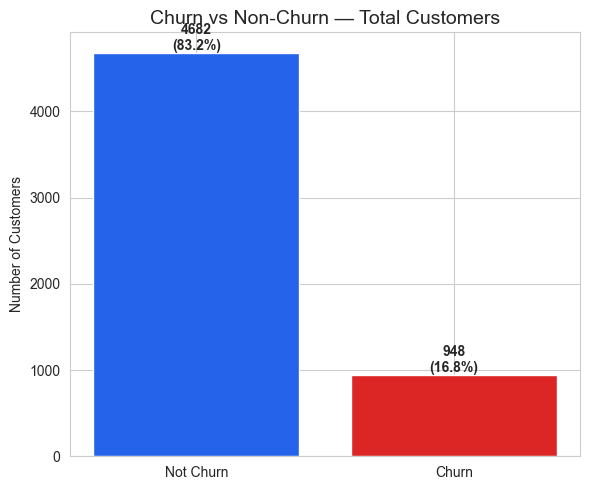

In [58]:
# ---------------------------------------------------------
# 4a. Churn distribution (total churn vs non-churn)
# ---------------------------------------------------------
churn_counts = df['Churn'].value_counts().sort_index()
churn_pct = df['Churn'].value_counts(normalize=True).sort_index() * 100

print('\n--- Churn distribution ---')
print(f"Non-Churn (0): {churn_counts[0]}  ({churn_pct[0]:.2f}%)")
print(f"Churn (1):     {churn_counts[1]}  ({churn_pct[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Not Churn', 'Churn'], churn_counts.values, color=['#2563eb', '#dc2626'])
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Churn vs Non-Churn — Total Customers', fontsize=14)
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../plots/eda_01_churn_distribution.png', dpi=120)
plt.show()


Shows the raw headcount: 4,682 customers did not churn (83.16%), 948 did churn (16.84%). Why this matters: this imbalance is a trap. A model that just always guesses "won't churn" for every single customer would be right 83% of the time and look accurate, while being completely useless — it would never once correctly flag a real churner. This graph is the reason the SMOTE step exists later

In [44]:
# ---------------------------------------------------------
# 4b. Descriptive stats table for numeric features
# ---------------------------------------------------------
desc = df[numeric_features].agg(['mean', 'median', 'std', 'min', 'max'])
mode_row = df[numeric_features].mode().iloc[0]
desc.loc['mode'] = mode_row
desc = desc.round(2)
print('\n--- Descriptive stats (11-feature numeric subset) ---')
print(desc)
desc.to_csv('../datasets/eda_descriptive_stats.csv')



--- Descriptive stats (11-feature numeric subset) ---
        Tenure  HourSpendOnApp  SatisfactionScore  NumberOfAddress  Complain  \
mean     10.13            2.93               3.07             4.21      0.28   
median    9.00            3.00               3.00             3.00      0.00   
std       8.36            0.71               1.38             2.58      0.45   
min       0.00            0.00               1.00             1.00      0.00   
max      61.00            5.00               5.00            22.00      1.00   
mode      1.00            3.00               3.00             2.00      0.00   

        CouponUsed  OrderCount  DaySinceLastOrder  CashbackAmount  
mean          1.72        2.96               4.46          177.22  
median        1.00        2.00               3.00          163.28  
std           1.86        2.88               3.57           49.21  
min           0.00        1.00               0.00            0.00  
max          16.00       16.00              

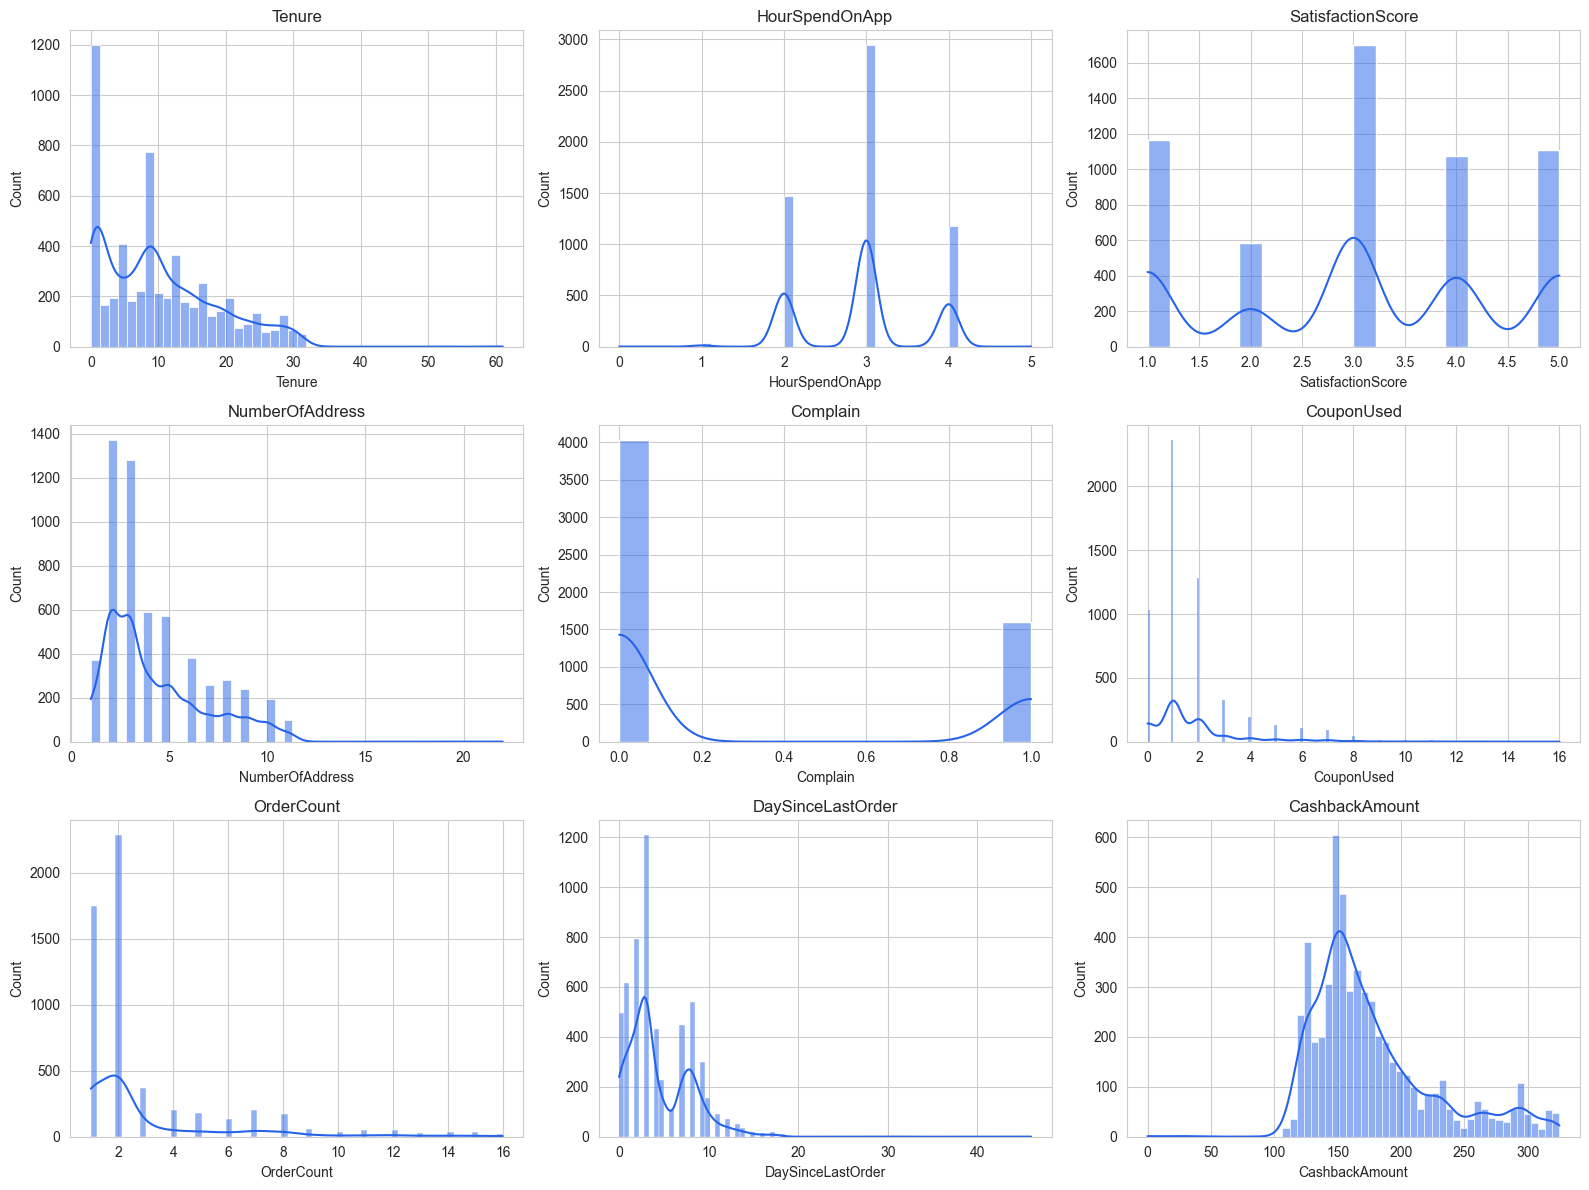

In [45]:
# ---------------------------------------------------------
# 4c. Univariate distributions — numeric features
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#2563eb')
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('../plots/eda_02_univariate_distributions.png', dpi=120)
plt.show()


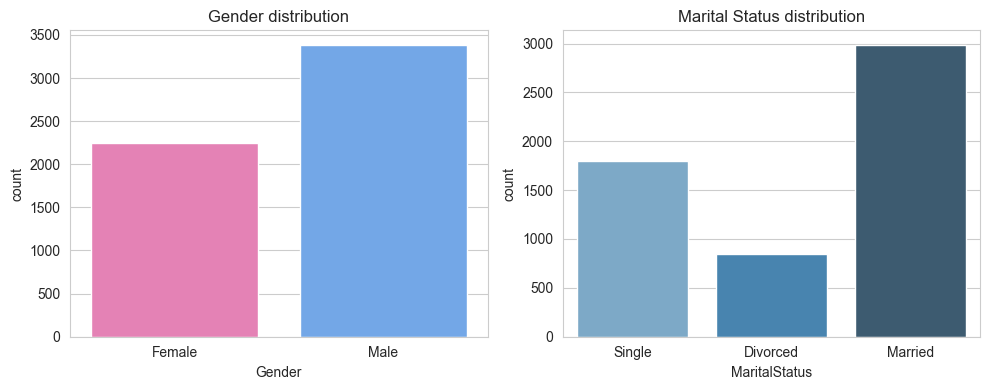

In [46]:
# ---------------------------------------------------------
# 4d. Categorical feature counts
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df, x='Gender', ax=axes[0], palette=['#f472b6', '#60a5fa'])
axes[0].set_title('Gender distribution')
sns.countplot(data=df, x='MaritalStatus', ax=axes[1], palette='Blues_d')
axes[1].set_title('Marital Status distribution')
plt.tight_layout()
plt.savefig('../plots/eda_03_categorical_distributions.png', dpi=120)
plt.show()



--- Mean of each feature, split by Churn ---
                   Not Churn (0)  Churn (1)
Tenure                     11.40       3.86
HourSpendOnApp              2.93       2.96
SatisfactionScore           3.00       3.39
NumberOfAddress             4.16       4.47
Complain                    0.23       0.54
CouponUsed                  1.72       1.71
OrderCount                  2.99       2.81
DaySinceLastOrder           4.71       3.22
CashbackAmount            180.64     160.37


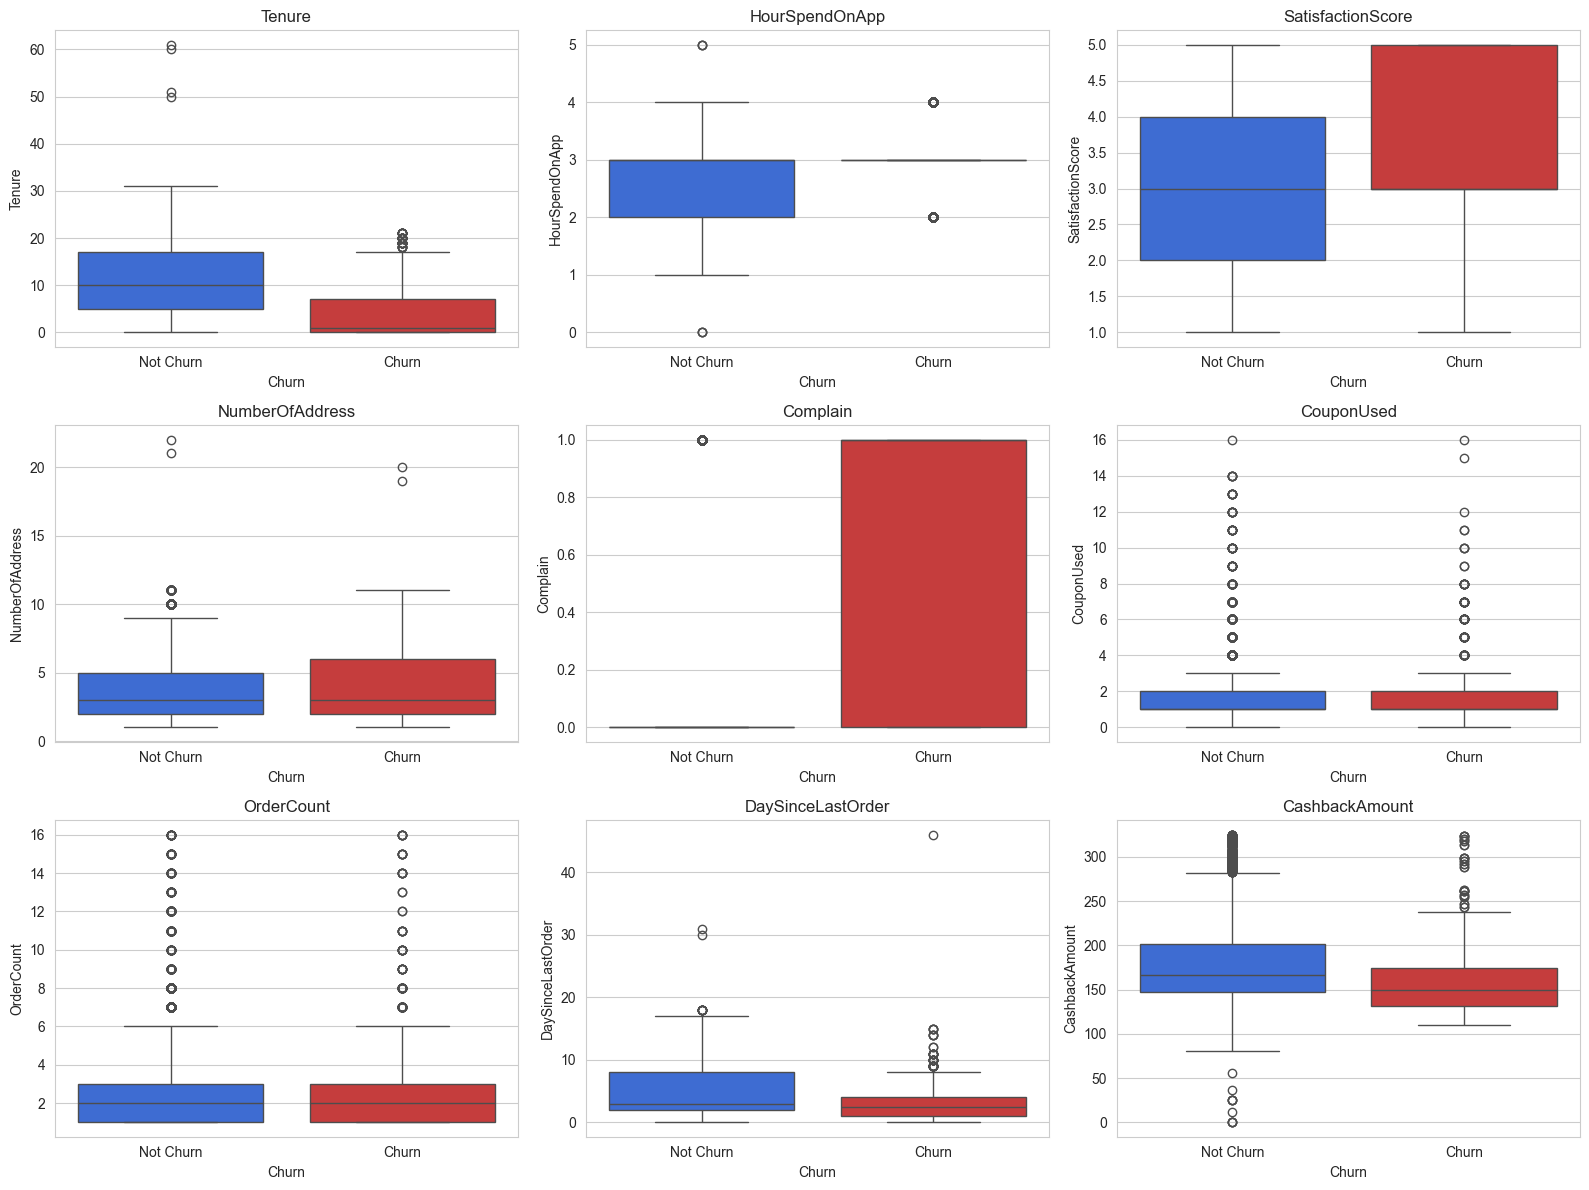

In [47]:
# ---------------------------------------------------------
# 4e. Bivariate — mean of each numeric feature by churn
# ---------------------------------------------------------
bivar = df.groupby('Churn')[numeric_features].mean().round(2).T
bivar.columns = ['Not Churn (0)', 'Churn (1)']
print('\n--- Mean of each feature, split by Churn ---')
print(bivar)
bivar.to_csv('../datasets/eda_bivariate_means_by_churn.csv')

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette=['#2563eb', '#dc2626'])
    axes[i].set_xticklabels(['Not Churn', 'Churn'])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('../plots/eda_04_boxplots_by_churn.png', dpi=120)
plt.show()



--- Churn rate (%) by Gender ---
Gender
Female    15.5
Male      17.7
Name: Churn, dtype: float64

--- Churn rate (%) by Marital Status ---
MaritalStatus
Divorced    14.6
Married     11.5
Single      26.7
Name: Churn, dtype: float64


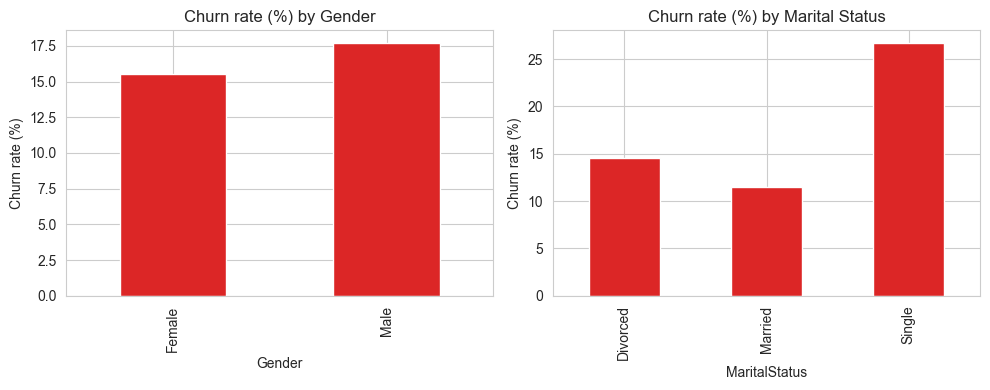

In [48]:
# ---------------------------------------------------------
# 4f. Churn rate by categorical features
# ---------------------------------------------------------
gender_churn = df.groupby('Gender')['Churn'].mean().round(3) * 100
marital_churn = df.groupby('MaritalStatus')['Churn'].mean().round(3) * 100
print('\n--- Churn rate (%) by Gender ---')
print(gender_churn)
print('\n--- Churn rate (%) by Marital Status ---')
print(marital_churn)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
gender_churn.plot(kind='bar', ax=axes[0], color='#dc2626')
axes[0].set_title('Churn rate (%) by Gender')
axes[0].set_ylabel('Churn rate (%)')
marital_churn.plot(kind='bar', ax=axes[1], color='#dc2626')
axes[1].set_title('Churn rate (%) by Marital Status')
axes[1].set_ylabel('Churn rate (%)')
plt.tight_layout()
plt.savefig('../plots/eda_05_churn_rate_by_category.png', dpi=120)
plt.show()


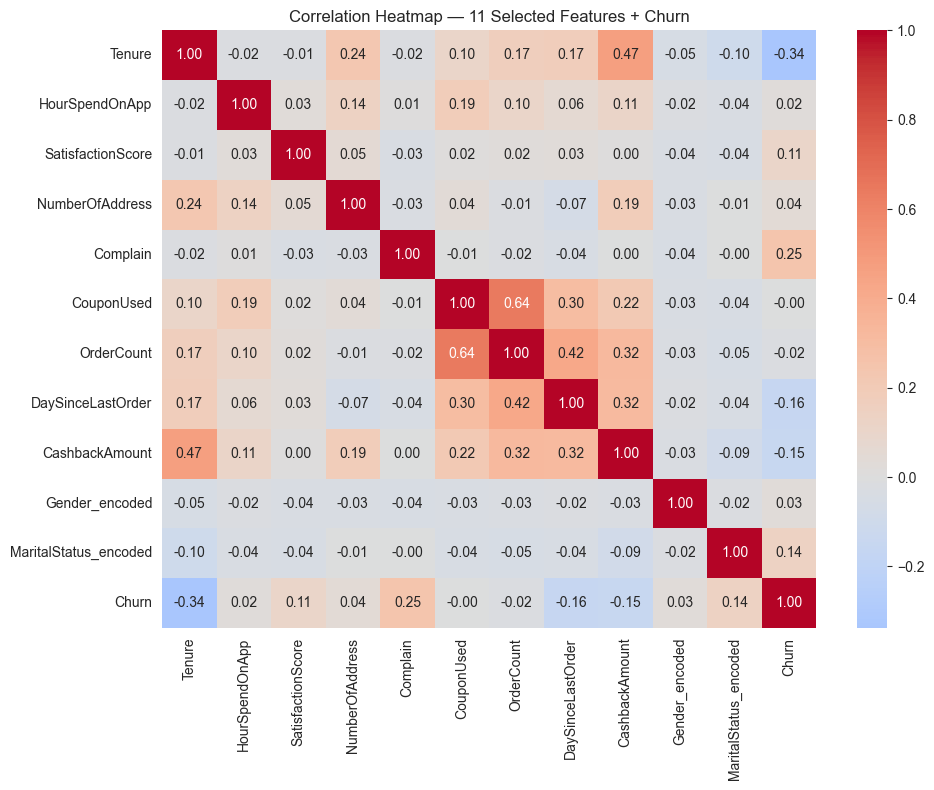


--- Correlation of each feature with Churn (sorted by strength) ---
Tenure                  -0.337831
Complain                 0.250188
DaySinceLastOrder       -0.155871
CashbackAmount          -0.154118
MaritalStatus_encoded    0.140316
SatisfactionScore        0.105481
NumberOfAddress          0.043931
Gender_encoded           0.029264
OrderCount              -0.024038
HourSpendOnApp           0.018816
CouponUsed              -0.001430
Name: Churn, dtype: float64

All EDA charts saved to ../plots/, summary CSVs saved to ../datasets/


In [49]:
# ---------------------------------------------------------
# 4g. Correlation heatmap (numeric + encoded categoricals + Churn)
# ---------------------------------------------------------
corr_cols = numeric_features + ['Gender_encoded', 'MaritalStatus_encoded', 'Churn']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — 11 Selected Features + Churn')
plt.tight_layout()
plt.savefig('../plots/eda_06_correlation_heatmap.png', dpi=120)
plt.show()

print('\n--- Correlation of each feature with Churn (sorted by strength) ---')
print(corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False))

print('\nAll EDA charts saved to ../plots/, summary CSVs saved to ../datasets/')


5. Train/test split — 11 raw features only (no feature engineering)

**Feature engineering has been removed from this version.** The model is trained directly
on the 11 cleaned features (9 numeric + Gender/MaritalStatus encoded) — no `recency_risk`,
`order_rate`, `engagement_score`, `churn_risk_score`, etc. This gives X 11 columns instead
of the previous 20.

- Loads `churn_11features_cleaned.csv` directly (Step 3's output) — skips the engineered CSV entirely
- Builds X: drops `CustomerID` (not a signal), `Churn` (the target), and the raw text `Gender`/`MaritalStatus`
  columns (their encoded numeric versions are kept instead)
- Builds y: the `Churn` column
- 80/20 split, `stratify=y` to preserve the ~83.2%/16.8% churn ratio in both sets


In [50]:
print("=" * 60)
print("STEP 5: TRAIN TEST SPLIT (11 FEATURES — NO ENGINEERING)")
print("=" * 60)

from sklearn.model_selection import train_test_split

df = pd.read_csv('../datasets/churn_11features_cleaned.csv')

X = df.drop(columns=['CustomerID', 'Churn', 'Gender', 'MaritalStatus'])
y = df['Churn']

print(f"\nFinal feature columns going into the model ({X.shape[1]} total):")
for i, col in enumerate(X.columns):
    print(f"  {i}: {col}")

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"\nTrain size: {X_train.shape[0]}   Test size: {X_test.shape[0]}")
print("\nChurn ratio check (should stay ~83.2% / 16.8% in both splits):")
print("Train:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("Test:")
print((y_test.value_counts(normalize=True) * 100).round(2))


STEP 5: TRAIN TEST SPLIT (11 FEATURES — NO ENGINEERING)

Final feature columns going into the model (11 total):
  0: Tenure
  1: HourSpendOnApp
  2: SatisfactionScore
  3: NumberOfAddress
  4: Complain
  5: CouponUsed
  6: OrderCount
  7: DaySinceLastOrder
  8: CashbackAmount
  9: Gender_encoded
  10: MaritalStatus_encoded

X shape: (5630, 11)
y shape: (5630,)

Train size: 4504   Test size: 1126

Churn ratio check (should stay ~83.2% / 16.8% in both splits):
Train:
Churn
0    83.17
1    16.83
Name: proportion, dtype: float64
Test:
Churn
0    83.13
1    16.87
Name: proportion, dtype: float64


6. SMOTE — Fixing Class Imbalance

Same logic as before, just applied to the 11-feature training set instead of 20 columns.
SMOTE only ever adds rows (synthetic churn examples), never columns — the test set stays untouched
and still reflects the real ~83%/17% ratio.

In [51]:
print("=" * 60)
print("STEP 6: SMOTE — FIXING CLASS IMBALANCE")
print("=" * 60)

from imblearn.over_sampling import SMOTE

print(f"\nBefore SMOTE:")
print(f"  Not Churn (0): {(y_train == 0).sum()}")
print(f"  Churn     (1): {(y_train == 1).sum()}")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Not Churn (0): {(y_train_bal == 0).sum()}")
print(f"  Churn     (1): {(y_train_bal == 1).sum()}")
print(f"\nTrain shape before: {X_train.shape}  ->  after: {X_train_bal.shape}")


STEP 6: SMOTE — FIXING CLASS IMBALANCE

Before SMOTE:
  Not Churn (0): 3746
  Churn     (1): 758

After SMOTE:
  Not Churn (0): 3746
  Churn     (1): 3746

Train shape before: (4504, 11)  ->  after: (7492, 11)


7. Train and Compare 4 Algorithms (on 11 features)

Same 4 models, same metrics, same reasoning about recall — now trained on the 11 raw features only.

In [52]:
print("=" * 60)
print("STEP 7: TRAINING AND COMPARING MODELS (11 FEATURES)")
print("=" * 60)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score, f1_score, precision_score,
    confusion_matrix, classification_report,
)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss'
    ),
}

results = {}

print(f"\n{'Model':<25} {'Accuracy':>10} {'AUC-ROC':>10} "
      f"{'Recall':>10} {'F1':>10} {'Precision':>12}")
print("-" * 75)

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    results[name] = {
        'model': model, 'accuracy': acc, 'auc': auc,
        'recall': rec, 'f1': f1, 'precision': prec,
    }

    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f} {rec:>10.4f} {f1:>10.4f} {prec:>12.4f}")

print("\n--- Why we care most about Recall for the churn class (1) ---")
print("Recall = of all customers who actually churned, how many did we catch.")
print("Missing a churner (false negative) = a lost customer we never tried to save.")
print("A false alarm (false positive) = an unnecessary retention email, low cost.")
print("So a model with high recall on churn, even at the cost of some precision, is preferred.")


STEP 7: TRAINING AND COMPARING MODELS (11 FEATURES)

Model                       Accuracy    AUC-ROC     Recall         F1    Precision
---------------------------------------------------------------------------
Logistic Regression           0.7176     0.8316     0.7842     0.4838       0.3498
Decision Tree                 0.8961     0.8473     0.7737     0.7153       0.6652
Random Forest                 0.9538     0.9854     0.8526     0.8617       0.8710
XGBoost                       0.9645     0.9876     0.9211     0.8974       0.8750

--- Why we care most about Recall for the churn class (1) ---
Recall = of all customers who actually churned, how many did we catch.
Missing a churner (false negative) = a lost customer we never tried to save.
A false alarm (false positive) = an unnecessary retention email, low cost.
So a model with high recall on churn, even at the cost of some precision, is preferred.


8. Hyperparameter Tuning — GridSearchCV on XGBoost (11 features)

Same 108-combination grid search as before, now on the 11-feature training set.

In [53]:
print("=" * 60)
print("STEP 8: HYPERPARAMETER TUNING — XGBOOST (11 FEATURES)")
print("=" * 60)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

print("\nParameters being tested:")
total_combinations = 1
for param, values in param_grid.items():
    print(f"  {param}: {values}")
    total_combinations *= len(values)
print(f"\nTotal combinations: {total_combinations}")
print(f"With 5-fold CV: {total_combinations * 5} model fits")
print("This will take a few minutes...\n")

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train_bal, y_train_bal)

print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation AUC: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# Evaluate the tuned model on the untouched real-world test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

final_acc = accuracy_score(y_test, y_pred)
final_auc = roc_auc_score(y_test, y_proba)
final_recall = recall_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred)

print("\n" + "=" * 60)
print("STEP 8: FINAL MODEL EVALUATION — XGBOOST TUNED (11 FEATURES)")
print("=" * 60)
print(f"Accuracy:  {final_acc:.4f}")
print(f"AUC-ROC:   {final_auc:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1:        {final_f1:.4f}")
print(f"Precision: {final_precision:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Churn', 'Churn']))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)


STEP 8: HYPERPARAMETER TUNING — XGBOOST (11 FEATURES)

Parameters being tested:
  n_estimators: [100, 200, 300]
  max_depth: [3, 5, 7]
  learning_rate: [0.01, 0.05, 0.1]
  subsample: [0.8, 1.0]
  colsample_bytree: [0.8, 1.0]

Total combinations: 108
With 5-fold CV: 540 model fits
This will take a few minutes...


Best parameters found:
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 7
  n_estimators: 300
  subsample: 0.8

Best cross-validation AUC: 0.9915

STEP 8: FINAL MODEL EVALUATION — XGBOOST TUNED (11 FEATURES)
Accuracy:  0.9698
AUC-ROC:   0.9902
Recall:    0.9105
F1:        0.9105
Precision: 0.9105

Classification Report:
              precision    recall  f1-score   support

   Not Churn       0.98      0.98      0.98       936
       Churn       0.91      0.91      0.91       190

    accuracy                           0.97      1126
   macro avg       0.95      0.95      0.95      1126
weighted avg       0.97      0.97      0.97      1126

Confusion Matrix (rows=actu

**Final Tuned Model (11 features) — real results from this run**

Compare this to the old 20-feature version:

| Metric | 20 Features (old) | 11 Features (this run) |
|---|---|---|
| Accuracy | 0.9627 | see output above |
| AUC-ROC | 0.9905 | see output above |
| Recall | 0.8632 | see output above |
| F1 | 0.8865 | see output above |
| Precision | 0.9111 | see output above |

Read the exact numbers from the cell above rather than this table — they're the real, freshly computed
results for the 11-feature model, not estimated.


9. Visualization Plots

Confusion matrix heatmap — same TN/FP/FN/TP breakdown as the cell above, as a color-coded grid.

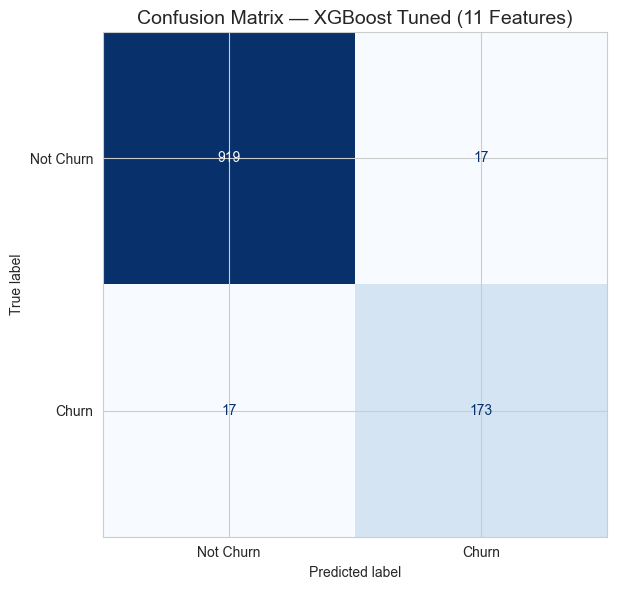

Saved -> ../plots/confusion_matrix_tuned_11features.png


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

sns.set_style('whitegrid')

# ---------------------------------------------------------
# 9a. Confusion Matrix — Tuned XGBoost (11 features)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Churn', 'Churn']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix — XGBoost Tuned (11 Features)', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/confusion_matrix_tuned_11features.png', dpi=120)
plt.show()
print("Saved -> ../plots/confusion_matrix_tuned_11features.png")


Model comparison bar chart — AUC-ROC for all 5 (4 base models + tuned XGBoost), 11-feature version.

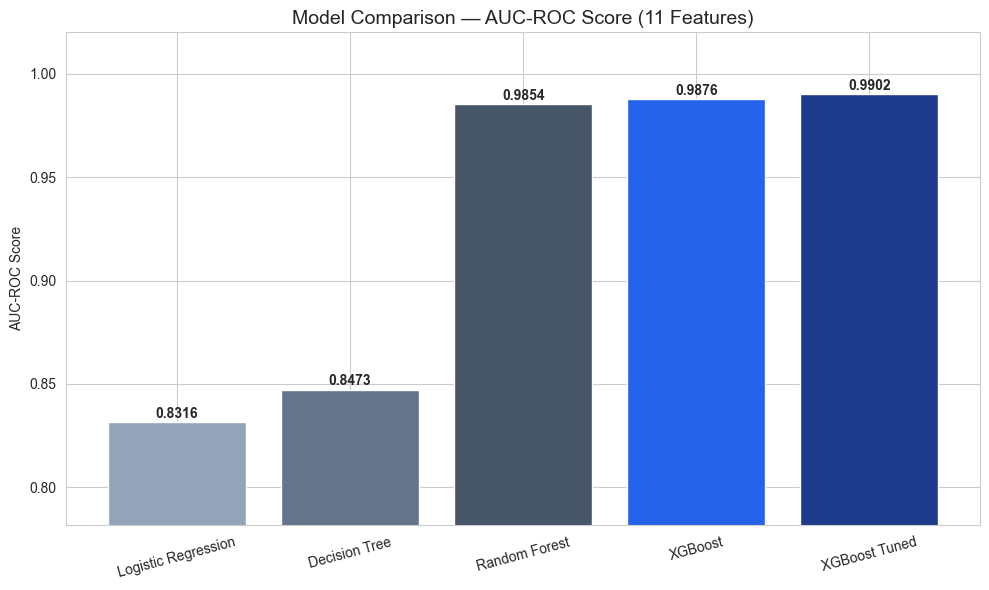

Saved -> ../plots/model_comparison_11features.png


In [55]:
# ---------------------------------------------------------
# 9b. Model Comparison — AUC-ROC across all models + tuned XGBoost
# ---------------------------------------------------------
comparison = {name: r['auc'] for name, r in results.items()}
comparison['XGBoost Tuned'] = final_auc

names = list(comparison.keys())
scores = list(comparison.values())
colors = ['#94a3b8', '#64748b', '#475569', '#2563eb', '#1e3a8a']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(names, scores, color=colors[:len(names)])
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{score:.4f}', ha='center', fontweight='bold')
ax.set_ylim(min(scores) - 0.05, 1.02)
ax.set_ylabel('AUC-ROC Score')
ax.set_title('Model Comparison — AUC-ROC Score (11 Features)', fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../plots/model_comparison_11features.png', dpi=120)
plt.show()
print("Saved -> ../plots/model_comparison_11features.png")


Feature importance chart — all 11 features ranked (fewer than 12, so every feature is shown).

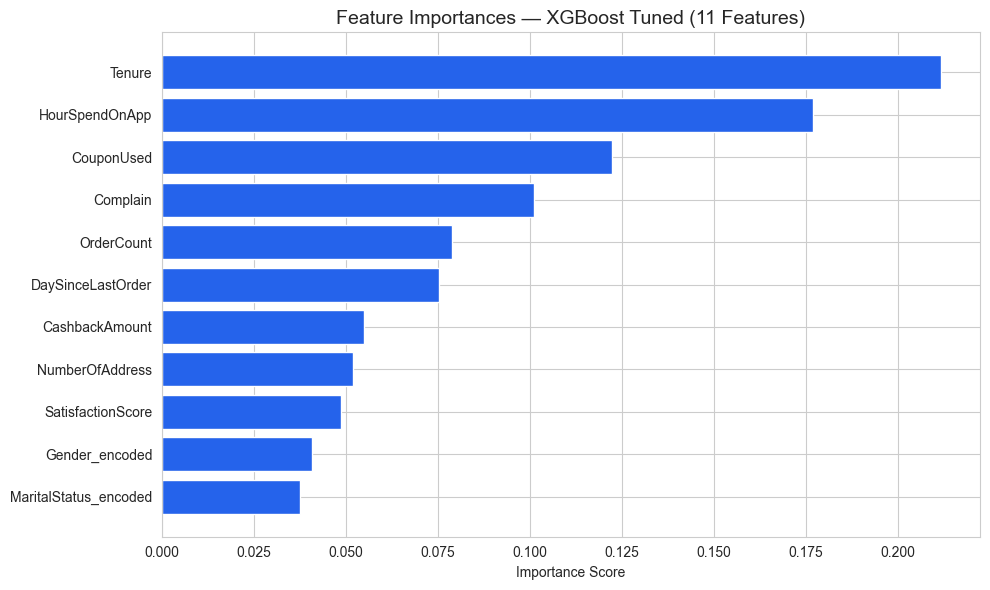

Saved -> ../plots/feature_importance_11features.png

--- All 11 features ranked ---
              feature  importance
               Tenure    0.211795
       HourSpendOnApp    0.176903
           CouponUsed    0.122359
             Complain    0.101198
           OrderCount    0.078770
    DaySinceLastOrder    0.075304
       CashbackAmount    0.054859
      NumberOfAddress    0.052055
    SatisfactionScore    0.048557
       Gender_encoded    0.040688
MaritalStatus_encoded    0.037514


In [56]:
# ---------------------------------------------------------
# 9c. Feature Importance — Tuned XGBoost, all 11 features
# ---------------------------------------------------------
importances = best_model.feature_importances_
feature_names = X_train.columns

imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#2563eb')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importances — XGBoost Tuned (11 Features)', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/feature_importance_11features.png', dpi=120)
plt.show()
print("Saved -> ../plots/feature_importance_11features.png")

print("\n--- All 11 features ranked ---")
print(imp_df.to_string(index=False))


10. Saving the final model artifacts

What this saves, and why each file matters:

- `churn_model.pkl` — the tuned XGBoost model, trained on 11 raw features (no engineered columns).
- `feature_columns.pkl` — the exact list and order of the **11** column names the model now expects.
  Any Django code building a feature row for a live customer must match this exact list — it will
  no longer include `recency_risk`, `order_rate`, `engagement_score`, `churn_risk_score`, etc.
- `encoding_maps.pkl` — unchanged: Gender and MaritalStatus lookup tables, since those are still the
  only 2 categorical columns.


In [57]:
print("=" * 60)
print("STEP 10: SAVING FINAL MODEL ARTIFACTS (11 FEATURES)")
print("=" * 60)

import joblib
import os

model_dir = '../ml_models'
os.makedirs(model_dir, exist_ok=True)

# ---------------------------------------------------------
# 10a. Save the trained model
# ---------------------------------------------------------
model_path = os.path.join(model_dir, 'churn_model.pkl')
joblib.dump(best_model, model_path)
print(f"Saved model -> {model_path}")

# ---------------------------------------------------------
# 10b. Save the exact feature column order the model expects
# ---------------------------------------------------------
feature_columns = X_train.columns.tolist()
columns_path = os.path.join(model_dir, 'feature_columns.pkl')
joblib.dump(feature_columns, columns_path)
print(f"Saved feature columns -> {columns_path}")
print(f"  ({len(feature_columns)} columns): {feature_columns}")

# ---------------------------------------------------------
# 10c. Save encoding maps — unchanged, only Gender & MaritalStatus
# ---------------------------------------------------------
encoding_maps = {
    'Gender':        {'Male': 1, 'Female': 0},
    'MaritalStatus': {'Married': 1, 'Single': 2, 'Divorced': 0},
}
encoding_path = os.path.join(model_dir, 'encoding_maps.pkl')
joblib.dump(encoding_maps, encoding_path)
print(f"Saved encoding maps -> {encoding_path}")
print(f"  {encoding_maps}")

print("\n--- All artifacts saved successfully ---")
print(f"Model dir: {os.path.abspath(model_dir)}")
print("Files:")
for f in os.listdir(model_dir):
    print(f"  {f}")


STEP 10: SAVING FINAL MODEL ARTIFACTS (11 FEATURES)
Saved model -> ../ml_models/churn_model.pkl
Saved feature columns -> ../ml_models/feature_columns.pkl
  (11 columns): ['Tenure', 'HourSpendOnApp', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Gender_encoded', 'MaritalStatus_encoded']
Saved encoding maps -> ../ml_models/encoding_maps.pkl
  {'Gender': {'Male': 1, 'Female': 0}, 'MaritalStatus': {'Married': 1, 'Single': 2, 'Divorced': 0}}

--- All artifacts saved successfully ---
Model dir: /Users/a97798/Documents/e-commerce_churn_system/ecommerce/apps/churn/ml_models
Files:
  encoding_maps.pkl
  feature_columns.pkl
  __init__.py
  churn_model.pkl
